In [1]:
import pandas as pd
import numpy as np

cancers = ['ccRCC', 'Melanoma', 'NSCLC']

seeds = [42,0,1,2,3]

names = ['Avatars K5', 'Avatars K10', 'CTGAN', 'Gaussian Copula', 'Synthpop', 'TVAE']

Bivariate_Score_Dict = {}
for cancer in cancers:
    score_dict = {}
    for i, name in enumerate(names):
        methods_score = []
        for seed in seeds:
            datasets = [f'avatarsk5_{seed}', f'avatarsk10_{seed}',f'ctgan_{seed}',f'gaussiancopula_{seed}',f'synthpop_{seed}',f'tvae_{seed}']
            uni_clinical_score = np.load(f'../{cancer}/BroadUtility/PairwiseClinical/PairwiseClinical_{seed}/bivariate_{datasets[i]}_all.npy')
            score_clinical_1_seed = np.mean(uni_clinical_score)
            
            uni_omic_scores = np.load(f'../{cancer}/BroadUtility/PairwiseTranscriptomicsSimi/PairwiseTranscriptomicsSimi_{seed}/{datasets[i]}_all.npy')
            score_omic_1_seed = np.mean(uni_omic_scores)

            crossgroup_score = pd.read_csv(f'../{cancer}/BroadUtility/PairwiseCrossGroup/CrossGroup_{seed}/{datasets[i]}_cross_group_full.csv')["Score"].values
            mean_crossgroup = np.mean(crossgroup_score)
            overal_score_seed = (1/3)*(score_omic_1_seed+score_clinical_1_seed+mean_crossgroup)
            methods_score.append(overal_score_seed)
            
        score_dict[name] = methods_score
    Bivariate_Score_Dict[cancer] = score_dict

In [4]:
for cancer, synthetic_dict in Bivariate_Score_Dict.items():
    print(f"\n--- CANCER: {cancer} ---")

    header = f"{'Synthetic Method':<25} | {'Mean ± STD':^25}"
    print(header)
    print("-" * len(header))
    
    for syntheticdata, scores in synthetic_dict.items():
        avg = np.mean(scores)
        std = np.std(scores)
        
        score_display = f"{avg:.3f} ± {std:.3f}"
        
        print(f"{syntheticdata:<25} | {score_display:^25}")


--- CANCER: ccRCC ---
Synthetic Method          |        Mean ± STD        
-----------------------------------------------------
Avatars K5                |       0.954 ± 0.001      
Avatars K10               |       0.952 ± 0.001      
CTGAN                     |       0.849 ± 0.000      
Gaussian Copula           |       0.935 ± 0.002      
Synthpop                  |       0.905 ± 0.001      
TVAE                      |       0.805 ± 0.011      

--- CANCER: Melanoma ---
Synthetic Method          |        Mean ± STD        
-----------------------------------------------------
Avatars K5                |       0.934 ± 0.001      
Avatars K10               |       0.932 ± 0.000      
CTGAN                     |       0.916 ± 0.000      
Gaussian Copula           |       0.938 ± 0.001      
Synthpop                  |       0.925 ± 0.001      
TVAE                      |       0.908 ± 0.004      

--- CANCER: NSCLC ---
Synthetic Method          |        Mean ± STD        
----------

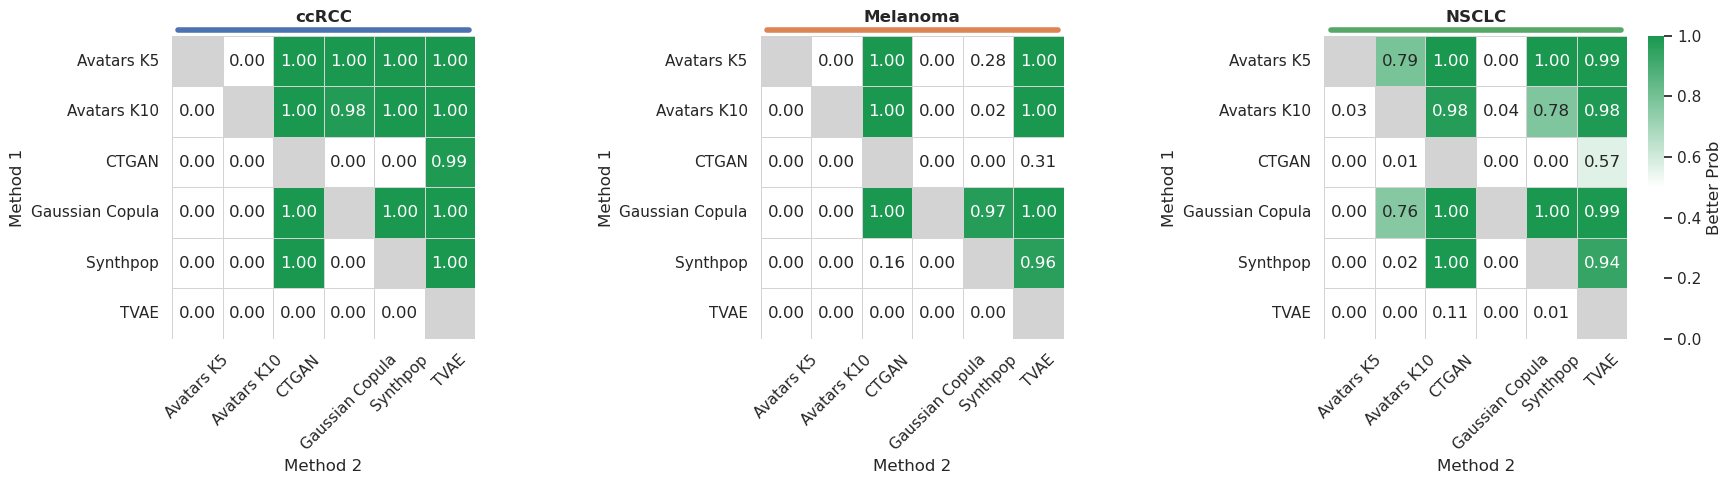

In [7]:
from SynOmics.metrics.fidelity.BayesianComparison import  BayesianComparison

bc = BayesianComparison(rope=0.01)
methods_order = ["Avatars K5", "Avatars K10", "CTGAN", "Gaussian Copula", "Synthpop", "TVAE"]
fig_c, axes, mats_by_cancer, comp_by_cancer = bc.plot_pbetter_heatmap_grid(
    cancer_to_method_scores=Bivariate_Score_Dict,
    cancers_order=["ccRCC", "Melanoma", "NSCLC"],
    methods_order=methods_order,
    value_col="Better Prob", 
    figsize=(18, 5),
    annot=True,
    fmt=".2f",
)

fig_c.savefig("bayesian_comp_fig3a_bi.pdf", bbox_inches="tight", facecolor="white")
for cancer in cancers:
    bayesian_comp_df = comp_by_cancer[cancer]
    bayesian_comp_df.to_csv(f'Bivariate_Bayesian_{cancer}.csv')